# Phase 3 推論・可視化 (BiomedCLIP 対応)

**目的**: 学習済み Stage 3b モデルを読み込み、歯科点群に対するパッチ‑テキスト類似度ヒートマップを可視化する。学習は行わない。

**テキストエンコーダ**: BiomedCLIP (`hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224`)  
**PatchToTextProj**: 384 → **512** 次元  
**カラーマップ**: `coolwarm` — 赤 = 高類似度 / 青 = 低類似度

---
**チェックリスト**
```
[ ] Google Drive マウント
[ ] GPU 確認
[ ] パッケージ & pointnet2_ops インストール
[ ] BiomedCLIP テキストエンコーダロード (テキスト次元 512)
[ ] モデルロード (Stage 3b best, clip_dim=512)
[ ] 患者選択 & 点群ロード
[ ] 静止ヒートマップ (全クエリ)
[ ] z軸回転 GIF 生成
```

## Step 0 — Google Drive マウント & パス設定

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys, os, types

DRIVE_ROOT  = '/content/drive/MyDrive'
REPO_ROOT   = f'{DRIVE_ROOT}/2026研究/ULIP_PointLLM'
PA3D_SRC    = f'{REPO_ROOT}/_reference_repos/PatchAlign3D/src'
PHASE3_DIR  = f'{REPO_ROOT}/DentalPatchAligned3D/Phase3_Training_v2'

# 重み (Phase3_Training_v2 で BiomedCLIP + clip_dim=512 で学習したもの)
CKPT_STAGE3B = f'{PHASE3_DIR}/outputs/stage3b/stage3b_best.pt'

# テストデータ
NPY_PATH = f'{REPO_ROOT}/DentalPatchAligned3D/Phase3_Training/Mandible_2048pts.npy'

# 出力先
OUT_DIR = f'{PHASE3_DIR}/inference_results'
os.makedirs(OUT_DIR, exist_ok=True)

# sys.path & patchalign3d 仮想パッケージ登録
for p in [PA3D_SRC, PHASE3_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

if 'patchalign3d' not in sys.modules:
    mod = types.ModuleType('patchalign3d')
    mod.__path__ = [PA3D_SRC]
    sys.modules['patchalign3d'] = mod

print(f'PHASE3_DIR : {PHASE3_DIR}')
print(f'CKPT       : {CKPT_STAGE3B}')
print(f'NPY_PATH   : {NPY_PATH}')
print(f'OUT_DIR    : {OUT_DIR}')

PHASE3_DIR : /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2
CKPT       : /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/outputs/stage3b/stage3b_best.pt
NPY_PATH   : /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/Mandible_2048pts.npy
OUT_DIR    : /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/inference_results


## Step 1 — GPU 確認

In [3]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device : {device}')
if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Step 2 — パッケージ & pointnet2_ops インストール

In [4]:
!pip install open_clip_torch>=2.24.0 timm easydict plyfile open3d imageio ninja -q
print('パッケージ OK')

パッケージ OK


In [5]:
import os, torch, shutil

%cd /content
if os.path.exists('/tmp/Pointnet2_PyTorch'):
    shutil.rmtree('/tmp/Pointnet2_PyTorch')

!git clone --quiet --depth 1 https://github.com/erikwijmans/Pointnet2_PyTorch.git /tmp/Pointnet2_PyTorch
!find /tmp/Pointnet2_PyTorch/pointnet2_ops_lib/pointnet2_ops/_ext-src/src -type f -exec sed -i 's/AT_CHECK/TORCH_CHECK/g' {} +
!find /tmp/Pointnet2_PyTorch/pointnet2_ops_lib/pointnet2_ops/_ext-src/src -type f -exec sed -i '/#include <THC\/THC.h>/d' {} +

major, minor = torch.cuda.get_device_capability()
new_arch = f'{major}.{minor}'
SETUP_PY = '/tmp/Pointnet2_PyTorch/pointnet2_ops_lib/setup.py'
!sed -i 's/os.environ\["TORCH_CUDA_ARCH_LIST"\] = .*/os.environ["TORCH_CUDA_ARCH_LIST"] = "{new_arch}"/g' {SETUP_PY}
print(f'GPU arch: {new_arch}')

%cd /tmp/Pointnet2_PyTorch/pointnet2_ops_lib
!pip install . -q
%cd /content

try:
    from knn_cuda import KNN
except ImportError:
    !pip install --upgrade https://github.com/unlimblue/KNN_CUDA/releases/download/0.2/KNN_CUDA-0.2-py3-none-any.whl -q

from pointnet2_ops import pointnet2_utils
from knn_cuda import KNN
print('pointnet2_ops + KNN_CUDA: OK')

/content
GPU arch: 7.5
/tmp/Pointnet2_PyTorch/pointnet2_ops_lib
  Preparing metadata (setup.py) ... done
/content
pointnet2_ops + KNN_CUDA: OK


## Step 3 — BiomedCLIP テキストエンコーダロード

> テキスト出力次元は **512** (v1 の ViT-bigG-14 / 1280 から変更)。  
> 初回は HuggingFace から数百 MB のダウンロードが発生します。

In [6]:
import open_clip
import torch
import torch.nn.functional as F

BIOMEDCLIP_HUB = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'

print(f'BiomedCLIP をロード中: {BIOMEDCLIP_HUB}')
clip_model, _, _ = open_clip.create_model_and_transforms(BIOMEDCLIP_HUB)
clip_model = clip_model.to(device)
clip_model.eval()
tokenizer = open_clip.get_tokenizer(BIOMEDCLIP_HUB)

def encode_texts(texts: list[str]) -> torch.Tensor:
    """テキストリストを正規化済み BiomedCLIP 特徴 (T, 512) に変換"""
    with torch.no_grad():
        toks = tokenizer(texts).to(device)
        feats = clip_model.encode_text(toks)
        return F.normalize(feats, dim=-1)

# 動作確認
test = encode_texts(['mandibular condyle'])
print(f'BiomedCLIP テキスト次元: {test.shape[-1]}  (期待: 512)')
assert test.shape[-1] == 512, (
    f'次元不一致: {test.shape[-1]}\n'
    'ヒント: 768 の場合は Step 4 の clip_dim を 768 に変更してください。'
)
print('BiomedCLIP ロード OK')

BiomedCLIP をロード中: hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BiomedCLIP テキスト次元: 512  (期待: 512)
BiomedCLIP ロード OK


## Step 4 — モデルロード (Stage 3b best)

> BiomedCLIP に対応するため `clip_dim=512` で構築します。  
> v1 の重み (`clip_dim=1280`) を誤って読み込むと `RuntimeError: size mismatch` が発生するので注意。

In [7]:
%cd {PHASE3_DIR}

/content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2


In [8]:
import os
import torch
from easydict import EasyDict
from phase3_models.stage3_model import build_stage3_models

# clip_dim=512: BiomedCLIP テキスト次元に合わせた PatchToTextProj (384→512)
cfg_model = EasyDict(
    trans_dim=384, depth=12, drop_path_rate=0.1, cls_dim=50,
    num_heads=6, group_size=32, num_group=128, encoder_dims=256,
    color=False, num_classes=16,
    clip_dim=512,   # BiomedCLIP
    clip_tau=0.07,
)

encoder, _, proj, _ = build_stage3_models(
    cfg=cfg_model, device=torch.device(device), ckpt_path=''
)

assert os.path.exists(CKPT_STAGE3B), f'重みが見つかりません: {CKPT_STAGE3B}'
ckpt = torch.load(CKPT_STAGE3B, map_location='cpu', weights_only=False)
encoder.load_state_dict(ckpt['student'], strict=False)
proj.load_state_dict(ckpt['proj'], strict=False)

encoder.eval().to(device)
proj.eval().to(device)

print(f'Stage 3b best (epoch {ckpt["epoch"]}) ロード完了')
print(f'  encoder params : {sum(p.numel() for p in encoder.parameters()):,}')
print(f'  proj    params : {sum(p.numel() for p in proj.parameters()):,}')
print(f'  proj shape     : {list(proj.proj.weight.shape)}  (期待: [512, 384])')

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[Stage3] Student: 学習可能 1,873,536 / 総 21,858,816 パラメータ  Proj: 197,120
Stage 3b best (epoch 830) ロード完了
  encoder params : 21,858,816
  proj    params : 197,120
  proj shape     : [512, 384]  (期待: [512, 384])


## Step 5 — NPY テストデータ読み込み

`Mandible_2048pts.npy` を読み込み、前 3 次元 (x, y, z) を使用してパッチ推論を行います。  
NPY は shape (2048, D) を想定 — D = 3/6/8 いずれにも対応。

In [9]:
import numpy as np

# テストデータ設定
SAMPLE_NAME = 'Mandible_2048pts'
print(f'NPY: {NPY_PATH}')
print(f'サンプル名: {SAMPLE_NAME}')

NPY: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/Mandible_2048pts.npy
サンプル名: Mandible_2048pts


In [10]:
from phase3_datasets.dental_dataset import _normalize_unit_sphere

# NPY 読み込み — shape (2048, D), D = 3/6/8 いずれにも対応
data = np.load(NPY_PATH)
xyz_np_raw = data[:2048, :3].astype(np.float32)   # 前3次元 XYZ を 2048 点分取得

print(f'NPY shape: {data.shape}  dtype: {data.dtype}')
print(f'XYZ 座標範囲: [{xyz_np_raw.min():.4f}, {xyz_np_raw.max():.4f}]')

# 単位球正規化
xyz_raw_t = torch.from_numpy(xyz_np_raw)          # (2048, 3)
xyz_n, centroid, scale = _normalize_unit_sphere(xyz_raw_t)
xyz_np = xyz_n.cpu().numpy()                       # NumPy (2048, 3)

pts_t = xyz_n.T.unsqueeze(0).to(device)           # (1, 3, 2048)

print(f'正規化後 座標範囲: [{xyz_np.min():.3f}, {xyz_np.max():.3f}]')

# パッチ推論
with torch.no_grad():
    patch_emb, patch_centers, patch_idx = encoder.forward_patches(pts_t)
    patch_feat = proj(patch_emb)                   # (1, G=128, 512)

centers = patch_centers[0].T.cpu().numpy()         # (128, 3)
print(f'patch_emb    : {patch_emb.shape}')
print(f'patch_feat   : {patch_feat.shape}  ← 512 次元 (BiomedCLIP)')
print(f'patch_centers: {patch_centers.shape}')

NPY shape: (2048, 6)  dtype: float32
XYZ 座標範囲: [0.0181, 0.1802]
正規化後 座標範囲: [-0.726, 0.732]
patch_emb    : torch.Size([1, 384, 128])
patch_feat   : torch.Size([1, 128, 512])  ← 512 次元 (BiomedCLIP)
patch_centers: torch.Size([1, 3, 128])


## Step 6 — テキストクエリ設定 & コサイン類似度算出

`TEXT_QUERIES` を自由に編集してください。

In [11]:
TEXT_QUERIES = [
    'left mandibular condyle',
    'right coronoid process',
    'left gonial angle',
    'right mandibular condyle',
    'left condylar neck',
    'right mandible body',
    'left ramus of mandible',
    'right mandibular notch',
]
print(f'テキストクエリ {len(TEXT_QUERIES)} 件')

# BiomedCLIP でテキストエンコード → (T, 512)
text_feats = encode_texts(TEXT_QUERIES)
print(f'text_feats: {text_feats.shape}  (期待: [T, 512])')

# コサイン類似度スコア計算
sim = (patch_feat[0] @ text_feats.T).cpu().numpy()   # (G=128, T)
print(f'類似度行列: {sim.shape}  [{sim.min():.3f}, {sim.max():.3f}]')

テキストクエリ 8 件
text_feats: torch.Size([8, 512])  (期待: [T, 512])
類似度行列: (128, 8)  [-0.351, 0.153]


## Step 7 — 静止ヒートマップ可視化

カラーマップ `coolwarm`: **赤 = 高類似度 / 青 = 低類似度**

/tmp/ipykernel_1475/64114143.py:33: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/64114143.py:33: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/64114143.py:33: UserWarning: Glyph 12481 (\N{KATAKANA LETTER TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/64114143.py:33: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/64114143.py:33: UserWarning: Glyph 12461 (\N{KATAKANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/64114143.py:33: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/64114143.py:33: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

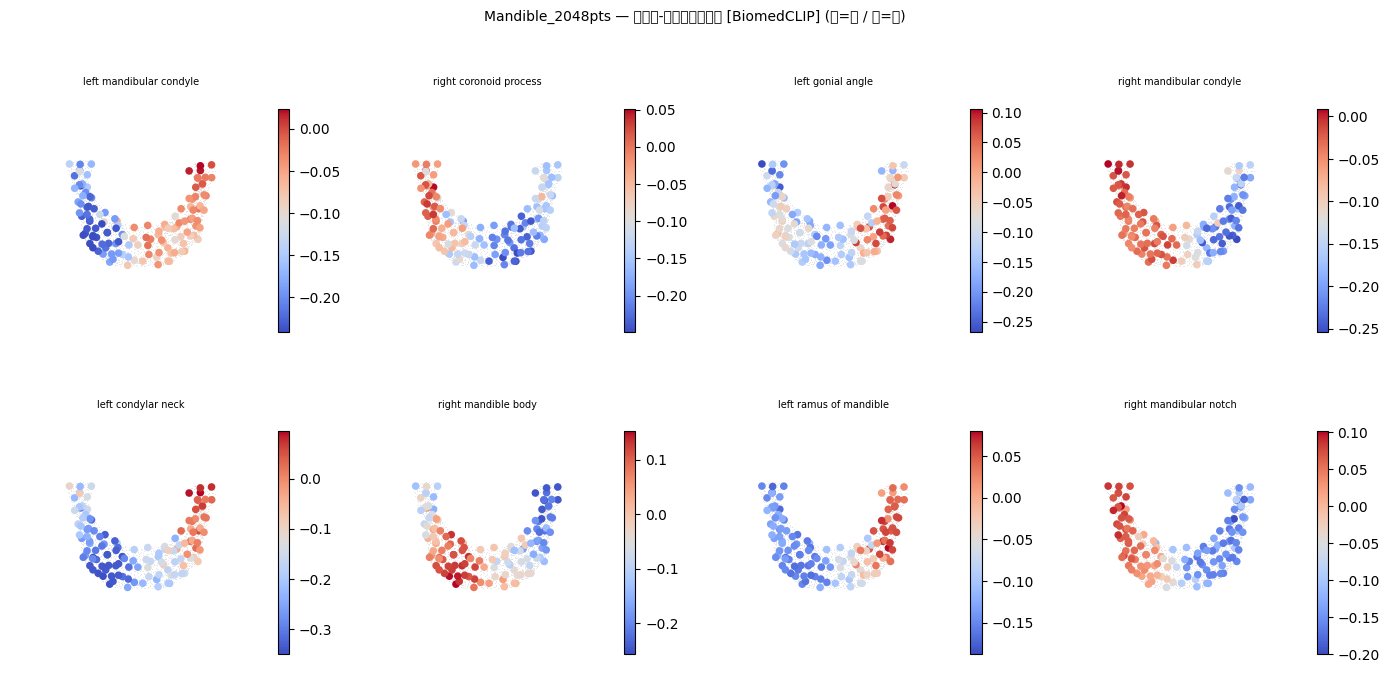

保存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/inference_results/Mandible_2048pts_heatmap_static.png


In [12]:
import matplotlib.pyplot as plt

n_queries = len(TEXT_QUERIES)
ncols = min(4, n_queries)
nrows = (n_queries + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 3.5, nrows * 3.5),
                          facecolor='white')
axes = np.array(axes).reshape(-1)

for i, (ax, query) in enumerate(zip(axes, TEXT_QUERIES)):
    sim_q = sim[:, i]
    ax.scatter(xyz_np[:, 0], xyz_np[:, 2],
               c='lightgray', s=0.5, alpha=0.4, linewidths=0)
    sc = ax.scatter(centers[:, 0], centers[:, 2],
                    c=sim_q, cmap='coolwarm', s=30,
                    vmin=sim_q.min(), vmax=sim_q.max(),
                    linewidths=0)
    plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
    short = query[:35] + ('...' if len(query) > 35 else '')
    ax.set_title(short, fontsize=7, pad=3)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.axis('off')

for ax in axes[n_queries:]:
    ax.set_visible(False)

fig.suptitle(f'{SAMPLE_NAME} — パッチ‑テキスト類似度 [BiomedCLIP] (赤=高 / 青=低)',
             fontsize=10, y=1.01)
plt.tight_layout()

save_path = os.path.join(OUT_DIR, f'{SAMPLE_NAME}_heatmap_static.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'保存: {save_path}')

## Step 8 — z 軸回転 GIF 生成

各テキストクエリについて、点群を z 軸周りに 10° ずつ回転させた GIF を保存する。

In [13]:
import imageio.v2 as imageio
import io

def rotate_z(xyz: np.ndarray, theta_deg: float) -> np.ndarray:
    theta = np.radians(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
    return xyz @ R.T


DEGREES_PER_FRAME = 10
N_FRAMES          = 360 // DEGREES_PER_FRAME
FPS               = 8

print(f'GIF 生成: {n_queries} クエリ × {N_FRAMES} フレーム (10°/frame, {FPS} fps)')

gif_paths = []
for qi, query in enumerate(TEXT_QUERIES):
    sim_q = sim[:, qi]
    vmin, vmax = float(sim_q.min()), float(sim_q.max())

    frames = []
    for angle in range(0, 360, DEGREES_PER_FRAME):
        xyz_rot     = rotate_z(xyz_np, angle)
        centers_rot = rotate_z(centers, angle)

        fig, ax = plt.subplots(figsize=(4, 4), facecolor='white')
        ax.scatter(xyz_rot[:, 0], xyz_rot[:, 2],
                   c='lightgray', s=0.5, alpha=0.4, linewidths=0)
        sc = ax.scatter(centers_rot[:, 0], centers_rot[:, 2],
                        c=sim_q, cmap='coolwarm', s=30,
                        vmin=vmin, vmax=vmax, linewidths=0)
        plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
        short = query[:30] + ('...' if len(query) > 30 else '')
        ax.set_title(f'{short}\n{angle:3d}°', fontsize=7, pad=3)
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_aspect('equal')
        ax.axis('off')
        plt.tight_layout(pad=0.4)

        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=90, bbox_inches='tight')
        buf.seek(0)
        frames.append(imageio.imread(buf))
        plt.close(fig)

    h = min(f.shape[0] for f in frames)
    w = min(f.shape[1] for f in frames)
    frames = [f[:h, :w] for f in frames]

    safe_name = query.replace(' ', '_').replace('/', '-')[:40]
    gif_path  = os.path.join(OUT_DIR, f'{SAMPLE_NAME}_{qi:02d}_{safe_name}.gif')
    imageio.mimsave(gif_path, frames, fps=FPS, loop=0)
    gif_paths.append(gif_path)
    print(f'  [{qi+1:2d}/{n_queries}] {gif_path}')

print(f'\n完了: {len(gif_paths)} 件の GIF を {OUT_DIR} に保存')

GIF 生成: 8 クエリ × 36 フレーム (10°/frame, 8 fps)
  [ 1/8] /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/inference_results/Mandible_2048pts_00_left_mandibular_condyle.gif
  [ 2/8] /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/inference_results/Mandible_2048pts_01_right_coronoid_process.gif
  [ 3/8] /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/inference_results/Mandible_2048pts_02_left_gonial_angle.gif
  [ 4/8] /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/inference_results/Mandible_2048pts_03_right_mandibular_condyle.gif
  [ 5/8] /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/inference_results/Mandible_2048pts_04_left_condylar_neck.gif
  [ 6/8] /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/inference_results/Mandible_2048pts_05_right_mandible_body.gif
  [ 7/8] /content/